#Problem Statement and Proposed Solution

Engineering and manufacturing organizations operate within highly complex systems characterized by fluctuating vendor performance, uncertain demand signals, and multi-layered operational constraints.

This notebook develops a prototype AI-powered decision support system for industrial operations, integrating structured vendor analytics with market intelligence through a combination of feature engineering, scoring models, and large language model (LLM)-augmented retrieval pipelines.

To ground this system in real-world data, the analysis leverages publicly available North American Industry Classification System (NAICS) datasets spanning 2018–2021. These datasets provide industry-level signals such as receipts, growth trends, and regional concentration, which are transformed into comparable features for downstream scoring and decision support.

#Data Loading & EDA

In [85]:
# Importing os
import os
from openai import OpenAI

# Instantiating API key for OpenAI LLM use
os.environ["OPENAI_API_KEY"] = "REMOVED"
client = OpenAI()

In [2]:
# Importing the necessary libraries
import requests
import pandas as pd
import numpy as np

In [86]:
# Importing requests
import requests

# Defining function to pull data one year at a time
def pull_data(year):
    url = (
        f"https://api.census.gov/data/timeseries/asm/area2017?"
        f"get=NAME,GEO_ID,NAICS2017_LABEL,NAICS2017,YEAR,EMP2020,RCPTOT"
        f"&for=state:*"
        f"&time={year}"
    )

    response = requests.get(url)

    print("Status code:", response.status_code)
    print("Response text:", response.text)

    try:
        response.raise_for_status()
    except requests.exceptions.HTTPError as e:
        print("HTTP error occurred:", e)
        print("Response text:", response.text)
        return None

    return response.json()

# Pulling data for multiple years
data = []
for year in range(2018, 2022):
    year_data = pull_data(year)
    if year_data:
        data.extend(year_data)

Streaming output truncated to the last 5000 lines.
["Arizona","0400000US04","Veneer, plywood, and engineered wood product manufacturing","3212","2021","0","614417","2021","04"],
["Arizona","0400000US04","Other wood product manufacturing","3219","2021","0","734266","2021","04"],
["Arizona","0400000US04","Paper manufacturing","322","2021","0","1603380","2021","04"],
["Arizona","0400000US04","Pulp, paper, and paperboard mills","3221","2021","0","190409","2021","04"],
["Arizona","0400000US04","Converted paper product manufacturing","3222","2021","0","1412971","2021","04"],
["Arizona","0400000US04","Printing and related support activities","323","2021","0","1267897","2021","04"],
["Arizona","0400000US04","Printing and related support activities","3231","2021","0","1267897","2021","04"],
["Arizona","0400000US04","Petroleum and coal products manufacturing","324","2021","0","493717","2021","04"],
["Arizona","0400000US04","Petroleum and coal products manufacturing","3241","2021","0","493717","2

In [87]:
# Convert to DataFrame
df = pd.DataFrame(data)

# Display the DataFrame info
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20850 entries, 0 to 20849
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   0       20850 non-null  object
 1   1       20850 non-null  object
 2   2       20850 non-null  object
 3   3       20850 non-null  object
 4   4       20850 non-null  object
 5   5       20850 non-null  object
 6   6       20850 non-null  object
 7   7       20850 non-null  object
 8   8       20850 non-null  object
dtypes: object(9)
memory usage: 1.4+ MB
None


In [89]:
# Checking data
df.describe()

,0,1,2,3,4,5,6,7,8
count,20850,20850,20850,20850,20850,20850,20850,20850,20850
unique,52,52,107,109,5,53,15215,5,52
top,Illinois,0400000US17,Printing and related support activities,31-33,2021,0,0,2021,17
freq,432,432,408,204,5220,20795,5130,5220,432


In [90]:
# Inspecting data
df.head()

,0,1,2,3,4,5,6,7,8
0,NAME,GEO_ID,NAICS2017_LABEL,NAICS2017,YEAR,EMP2020,RCPTOT,time,state
1,Alabama,0400000US01,Manufacturing,31-33,2018,0,137578434,2018,01
2,Alabama,0400000US01,Food manufacturing,311,2018,0,11712369,2018,01
3,Alabama,0400000US01,Animal food manufacturing,3111,2018,0,1292176,2018,01
4,Alabama,0400000US01,"Pulp, paper, and paperboard mills",3221,2018,0,6703055,2018,01


In [91]:
# Converting row 0 to column headers
df = pd.DataFrame(data[1:], columns=data[0])

In [92]:
df.head()

,NAME,GEO_ID,NAICS2017_LABEL,NAICS2017,YEAR,EMP2020,RCPTOT,time,state
0,Alabama,0400000US01,Manufacturing,31-33,2018,0,137578434,2018,01
1,Alabama,0400000US01,Food manufacturing,311,2018,0,11712369,2018,01
2,Alabama,0400000US01,Animal food manufacturing,3111,2018,0,1292176,2018,01
3,Alabama,0400000US01,"Pulp, paper, and paperboard mills",3221,2018,0,6703055,2018,01
4,Alabama,0400000US01,Aerospace product and parts manufacturing,3364,2018,0,2489402,2018,01


In [93]:
df.describe()

,NAME,GEO_ID,NAICS2017_LABEL,NAICS2017,YEAR,EMP2020,RCPTOT,time,state
count,20849,20849,20849,20849,20849,20849,20849,20849,20849
unique,52,52,107,109,5,53,15215,5,52
top,Colorado,0400000US08,Printing and related support activities,31-33,2021,0,0,2021,08
freq,432,432,408,204,5220,20795,5130,5220,432


In [10]:
# Importing SQLite for database use
import sqlite3

conn = sqlite3.connect("census_data.db")
cursor = conn.cursor()

In [96]:
# Converting column names to lower case
df.columns = df.columns.str.lower()

# Keeping one year column only
if "year" in df.columns:
    df = df.drop(columns=["year"])

df = df.rename(columns={"time": "year"})

# Removing aggregate NAICS rows like '31-33'
df = df[~df["naics2017"].astype(str).str.contains("-", na=False)]

# Converting numeric fields
df["naics2017"] = pd.to_numeric(df["naics2017"], errors="coerce")
df["rcptot"] = pd.to_numeric(df["rcptot"], errors="coerce")
df["year"] = pd.to_numeric(df["year"], errors="coerce")

# Dropping emp2020
if "emp2020" in df.columns:
    df = df.drop(columns=["emp2020"])

# Dropping rows missing critical fields
df = df.dropna(subset=["name", "naics2017", "naics2017_label", "rcptot", "year", "state"])

df.head()

,name,geo_id,naics2017_label,naics2017,rcptot,year,state
1,Alabama,0400000US01,Food manufacturing,311.0,11712369.0,2018.0,01
2,Alabama,0400000US01,Animal food manufacturing,3111.0,1292176.0,2018.0,01
3,Alabama,0400000US01,"Pulp, paper, and paperboard mills",3221.0,6703055.0,2018.0,01
4,Alabama,0400000US01,Aerospace product and parts manufacturing,3364.0,2489402.0,2018.0,01
5,Alabama,0400000US01,Ship and boat building,3366.0,1184181.0,2018.0,01


In [98]:
# Dropping dataframe into SQL
df.to_sql("asm_raw", conn, if_exists="replace", index=False)

20642

In [99]:
# Inspecting data
pd.read_sql_query("SELECT * FROM asm_raw LIMIT 5;", conn)

,name,geo_id,naics2017_label,naics2017,rcptot,year,state
0,Alabama,0400000US01,Food manufacturing,311.0,11712369.0,2018.0,01
1,Alabama,0400000US01,Animal food manufacturing,3111.0,1292176.0,2018.0,01
2,Alabama,0400000US01,"Pulp, paper, and paperboard mills",3221.0,6703055.0,2018.0,01
3,Alabama,0400000US01,Aerospace product and parts manufacturing,3364.0,2489402.0,2018.0,01
4,Alabama,0400000US01,Ship and boat building,3366.0,1184181.0,2018.0,01


In [100]:
# Reconfirming raw state count
pd.read_sql_query("""
SELECT COUNT(DISTINCT state) AS unique_states
FROM asm_raw;
""", conn)

,unique_states
0,51


In [101]:
#
pd.read_sql_query("""
SELECT COUNT(DISTINCT naics2017_label) AS unique_labels
FROM asm_raw;
""", conn)

,unique_labels
0,105


###First Insights:

Initial inspection confirms a structured panel dataset spanning U.S. regions and NAICS industry classifications over multiple years. Each observation represents a state–industry pairing with associated economic indicators, most notably total receipts, which serve as a proxy for industry-level revenue.

The dataset spans 51 regions (including Washington, D.C.), each associated with a unique geographic identifier. Across these regions, observations are distributed over 105 NAICS industry classifications, each defined by a standardized industry code.

The industry coverage is broad, encompassing major sectors such as agriculture, manufacturing (e.g., textiles, aerospace), and transportation, enabling cross-sector comparative analysis at the state level.

The rcptot variable represents total receipts in thousands of USD, requiring scaling for accurate economic interpretation.

In [14]:
# Creating cleaned SQL table

cursor.executescript("""
DROP TABLE IF EXISTS asm_clean;

CREATE TABLE asm_clean AS
SELECT
    name AS state_name,
    state AS state_fips,
    geo_id,
    CAST(naics2017 AS INTEGER) AS naics,
    naics2017_label AS industry,
    CAST(rcptot AS REAL) AS receipts,
    CAST(year AS INTEGER) AS year
FROM asm_raw
WHERE naics2017 IS NOT NULL
  AND rcptot IS NOT NULL
  AND year IS NOT NULL;
""")

conn.commit()

In [15]:
# Checking table
pd.read_sql_query("""
SELECT *
FROM asm_clean
LIMIT 10;
""", conn)

,state_name,state_fips,geo_id,naics,industry,receipts,year
0,Alabama,01,0400000US01,311,Food manufacturing,11712369.0,2018
1,Alabama,01,0400000US01,3111,Animal food manufacturing,1292176.0,2018
2,Alabama,01,0400000US01,3221,"Pulp, paper, and paperboard mills",6703055.0,2018
3,Alabama,01,0400000US01,3364,Aerospace product and parts manufacturing,2489402.0,2018
4,Alabama,01,0400000US01,3366,Ship and boat building,1184181.0,2018
5,Alabama,01,0400000US01,3112,Grain and oilseed milling,2086783.0,2018
6,Alabama,01,0400000US01,323,Printing and related support activities,263470.0,2018
7,Alabama,01,0400000US01,3113,Sugar and confectionery product manufacturing,99491.0,2018
8,Alabama,01,0400000US01,337,Furniture and related product manufacturing,2478904.0,2018
9,Alabama,01,0400000US01,3114,Fruit and vegetable preserving and specialty f...,10648.0,2018


In [102]:
# Producing new table for EDA
eda_df = pd.read_sql_query("""
SELECT
    receipts,
    year,
    naics,
    state_name,
    industry
FROM asm_clean;
""", conn)

eda_df.head()

,receipts,year,naics,state_name,industry
0,11712369.0,2018,311,Alabama,Food manufacturing
1,1292176.0,2018,3111,Alabama,Animal food manufacturing
2,6703055.0,2018,3221,Alabama,"Pulp, paper, and paperboard mills"
3,2489402.0,2018,3364,Alabama,Aerospace product and parts manufacturing
4,1184181.0,2018,3366,Alabama,Ship and boat building


In [103]:
# Establishing top 15 industries within data
top_industries = (
    eda_df
    .groupby("industry")["receipts"]
    .mean()
    .sort_values(ascending=False)
    .head(15)
    .index
)

filtered_df = eda_df[eda_df["industry"].isin(top_industries)]

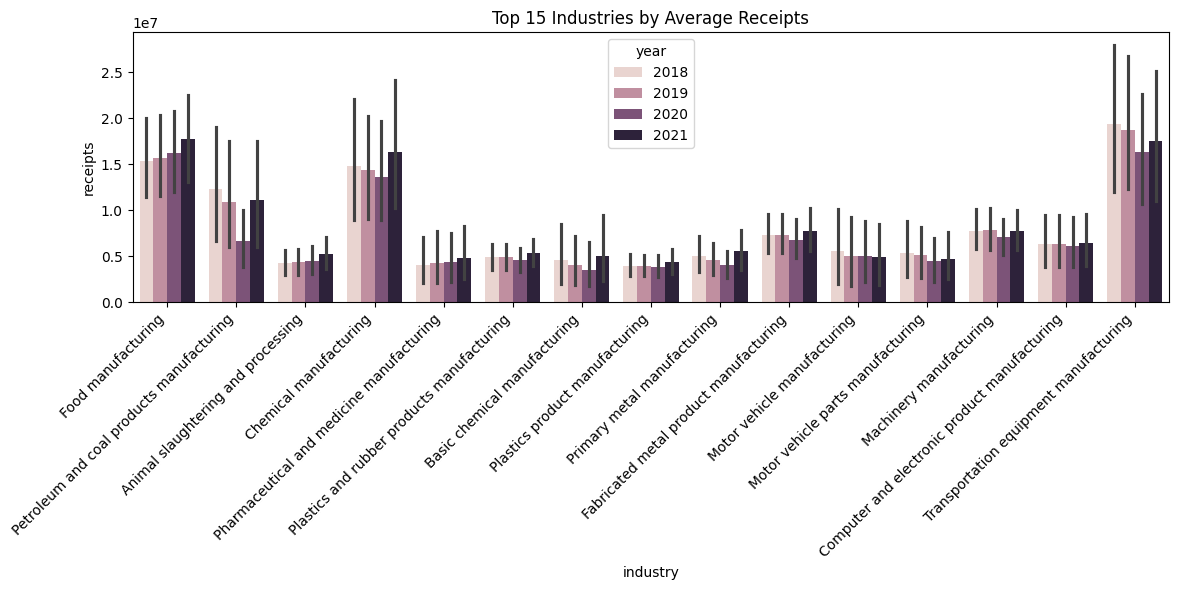

In [104]:
# Importing necessary libraries
import seaborn as sns
import matplotlib.pyplot as plt

# Visualizing the top 15 industries by total revenue per year
plt.figure(figsize=(12, 6))

sns.barplot(
    data=filtered_df,
    x="industry",
    y="receipts",
    hue="year",
    estimator="mean"
)

plt.xticks(rotation=45, ha="right")
plt.title("Top 15 Industries by Average Receipts")
plt.tight_layout()
plt.show()

In [105]:
# Selecting NAICS categories that are relevant to a large-scale industrial organizaton
relevant_df = pd.read_sql_query("""
SELECT *
FROM asm_clean
WHERE
    CAST(naics / 1 AS INTEGER) IN (332, 333, 334, 335, 336)
""", conn)

In [106]:
# Aggregating the select industries into single value: mean revenue
top_industries = (
    relevant_df
    .groupby("industry")["receipts"]
    .mean()
    .sort_values(ascending=False)
    .head(12)
    .index
)

filtered_df = relevant_df[relevant_df["industry"].isin(top_industries)]

In [107]:
# Generating initial revenue heatmap of relevant industries
heatmap_df = (
    filtered_df
    .groupby(["industry", "year"])["receipts"]
    .mean()
    .reset_index()
    .pivot(index="industry", columns="year", values="receipts")
)

In [108]:
# Applying log function to reduce scale bias
heatmap_log = np.log1p(heatmap_df)

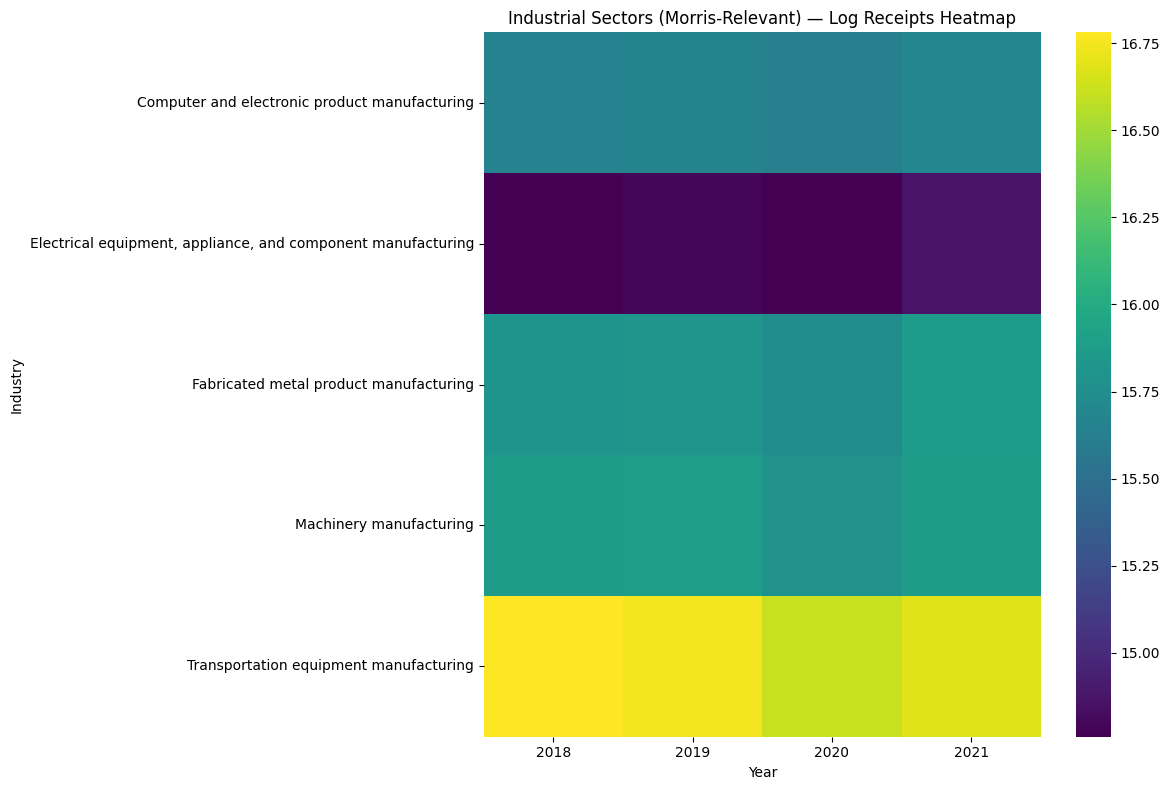

In [109]:
# Visualizing heatmap
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))

sns.heatmap(
    heatmap_log,
    annot=False,
    cmap="viridis"
)

plt.title("Industrial Sectors (Morris-Relevant) — Log Receipts Heatmap")
plt.xlabel("Year")
plt.ylabel("Industry")

plt.tight_layout()
plt.show()

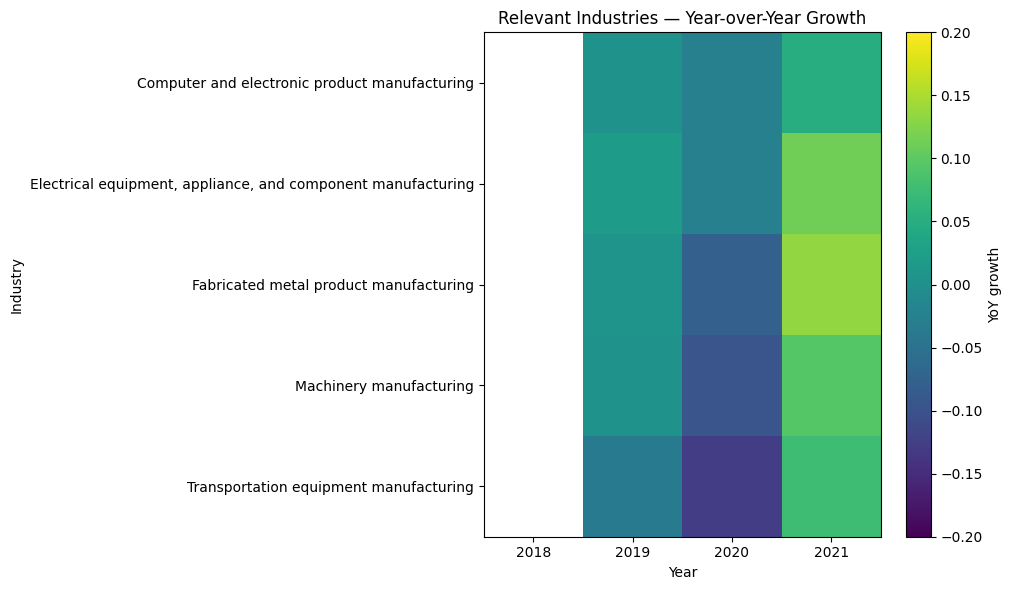

In [110]:
# Generating second heatmap to highlight annual growth
growth_df = pd.read_sql_query("""
WITH industry_year AS (
    SELECT
        industry,
        year,
        AVG(receipts) AS avg_receipts
    FROM asm_clean
    WHERE naics IN (332, 333, 334, 335, 336)
    GROUP BY industry, year
),
growth_calc AS (
    SELECT
        industry,
        year,
        avg_receipts,
        LAG(avg_receipts) OVER (
            PARTITION BY industry
            ORDER BY year
        ) AS prev_receipts
    FROM industry_year
)
SELECT
    industry,
    year,
    CASE
        WHEN prev_receipts IS NOT NULL AND prev_receipts != 0
        THEN (avg_receipts - prev_receipts) * 1.0 / prev_receipts
        ELSE NULL
    END AS growth
FROM growth_calc
ORDER BY industry, year;
""", conn)

growth_pivot = growth_df.pivot(index="industry", columns="year", values="growth")

plt.figure(figsize=(10, 6))
plt.imshow(growth_pivot, aspect="auto", vmin=-0.2, vmax=0.2)
plt.colorbar(label="YoY growth")
plt.xticks(range(len(growth_pivot.columns)), growth_pivot.columns)
plt.yticks(range(len(growth_pivot.index)), growth_pivot.index)
plt.title("Relevant Industries — Year-over-Year Growth")
plt.xlabel("Year")
plt.ylabel("Industry")
plt.tight_layout()
plt.show()

##Observations:

Preliminary exploration reveals substantial variation in both absolute receipts and growth trends across industries and regions, indicating strong heterogeneity in economic activity. This reinforces the need for normalization and feature scaling to enable meaningful cross-industry and cross-state comparisons.

An initial bar chart, segmented by year, shows that food manufacturing, chemical manufacturing, and transportation equipment manufacturing consistently rank among the highest-revenue industries across the observed period.

Given the focus of this notebook on industrial and manufacturing-related opportunities, subsequent analysis is scoped to a subset of relevant NAICS domains within this sector.

Within this subset, transportation equipment manufacturing emerges as a dominant contributor in absolute receipts, reflecting its capital-intensive nature and central role in broader supply chains.

Temporal trends also reveal a clear macroeconomic signal: 2020 exhibits a contraction across most industries, consistent with the economic disruption of the COVID-19 pandemic, followed by a broad recovery in 2021, with several industries demonstrating elevated growth rates relative to prior years.



#Initial Feature Engineering

In [22]:
# Filtering relevant industries in SQL
cursor.executescript("""
DROP TABLE IF EXISTS asm_relevant;

CREATE TABLE asm_relevant AS
SELECT *
FROM asm_clean
WHERE CAST(naics / 1 AS INTEGER) IN (332, 333, 334, 335, 336);
""")

conn.commit()

In [29]:
# Checking coverage
pd.read_sql_query("""
SELECT naics, industry, COUNT(*) AS rows_n
FROM asm_relevant
GROUP BY naics, industry
ORDER BY naics;
""", conn)

,naics,industry,rows_n
0,332,Fabricated metal product manufacturing,204
1,333,Machinery manufacturing,201
2,334,Computer and electronic product manufacturing,200
3,335,"Electrical equipment, appliance, and component...",200
4,336,Transportation equipment manufacturing,201


In [30]:
# Engineering features:
# prior year receipts
# year-over-year growth
# absolute change
# state-industry ranking context

cursor.executescript("""
DROP TABLE IF EXISTS asm_features;

CREATE TABLE asm_features AS
WITH base AS (
    SELECT
        state_name,
        state_fips,
        naics,
        industry,
        year,
        receipts,
        LAG(receipts) OVER (
            PARTITION BY state_name, naics
            ORDER BY year
        ) AS prev_receipts
    FROM asm_relevant
)
SELECT
    state_name,
    state_fips,
    naics,
    industry,
    year,
    receipts,
    prev_receipts,
    (receipts - prev_receipts) AS receipts_change,
    CASE
        WHEN prev_receipts IS NOT NULL AND prev_receipts != 0
        THEN (receipts - prev_receipts) * 1.0 / prev_receipts
        ELSE NULL
    END AS receipts_growth
FROM base;
""")

conn.commit()

In [31]:
# Reinspecting data
pd.read_sql_query("""
SELECT *
FROM asm_features
ORDER BY state_name, naics, year
LIMIT 20;
""", conn)

,state_name,state_fips,naics,industry,year,receipts,prev_receipts,receipts_change,receipts_growth
0,Alabama,01,332,Fabricated metal product manufacturing,2018,6681786.0,NaN,NaN,NaN
1,Alabama,01,332,Fabricated metal product manufacturing,2019,6778125.0,6681786.0,96339.0,0.014418
2,Alabama,01,332,Fabricated metal product manufacturing,2020,6299896.0,6778125.0,-478229.0,-0.070555
3,Alabama,01,332,Fabricated metal product manufacturing,2021,7234434.0,6299896.0,934538.0,0.148342
4,Alabama,01,333,Machinery manufacturing,2018,3008517.0,NaN,NaN,NaN
5,Alabama,01,333,Machinery manufacturing,2019,3052579.0,3008517.0,44062.0,0.014646
6,Alabama,01,333,Machinery manufacturing,2020,2521624.0,3052579.0,-530955.0,-0.173937
7,Alabama,01,333,Machinery manufacturing,2021,2837490.0,2521624.0,315866.0,0.125263
8,Alabama,01,334,Computer and electronic product manufacturing,2018,2264409.0,NaN,NaN,NaN
9,Alabama,01,334,Computer and electronic product manufacturing,2019,2481909.0,2264409.0,217500.0,0.096052


In [32]:
# Adding industry share within state-year

cursor.executescript("""
DROP TABLE IF EXISTS asm_features_enriched;

CREATE TABLE asm_features_enriched AS
WITH state_totals AS (
    SELECT
        state_name,
        year,
        SUM(receipts) AS state_total_receipts
    FROM asm_features
    GROUP BY state_name, year
)
SELECT
    f.*,
    s.state_total_receipts,
    CASE
        WHEN s.state_total_receipts IS NOT NULL AND s.state_total_receipts != 0
        THEN f.receipts * 1.0 / s.state_total_receipts
        ELSE NULL
    END AS state_industry_share
FROM asm_features f
LEFT JOIN state_totals s
    ON f.state_name = s.state_name
   AND f.year = s.year;
""")

conn.commit()

In [33]:
# Reinspecting
pd.read_sql_query("""
SELECT *
FROM asm_features_enriched
LIMIT 20;
""", conn)

,state_name,state_fips,naics,industry,year,receipts,prev_receipts,receipts_change,receipts_growth,state_total_receipts,state_industry_share
0,Alabama,01,332,Fabricated metal product manufacturing,2018,6681786.0,NaN,NaN,NaN,61413563.0,0.108800
1,Alabama,01,332,Fabricated metal product manufacturing,2019,6778125.0,6681786.0,96339.0,0.014418,62079793.0,0.109184
2,Alabama,01,332,Fabricated metal product manufacturing,2020,6299896.0,6778125.0,-478229.0,-0.070555,58049796.0,0.108526
3,Alabama,01,332,Fabricated metal product manufacturing,2021,7234434.0,6299896.0,934538.0,0.148342,63431410.0,0.114051
4,Alabama,01,333,Machinery manufacturing,2018,3008517.0,NaN,NaN,NaN,61413563.0,0.048988
5,Alabama,01,333,Machinery manufacturing,2019,3052579.0,3008517.0,44062.0,0.014646,62079793.0,0.049172
6,Alabama,01,333,Machinery manufacturing,2020,2521624.0,3052579.0,-530955.0,-0.173937,58049796.0,0.043439
7,Alabama,01,333,Machinery manufacturing,2021,2837490.0,2521624.0,315866.0,0.125263,63431410.0,0.044733
8,Alabama,01,334,Computer and electronic product manufacturing,2018,2264409.0,NaN,NaN,NaN,61413563.0,0.036871
9,Alabama,01,334,Computer and electronic product manufacturing,2019,2481909.0,2264409.0,217500.0,0.096052,62079793.0,0.039979


In [34]:
# Generating the fastest-growing state/industry combinations in the latest year

latest_year = pd.read_sql_query("""
SELECT MAX(year) AS latest_year
FROM asm_features_enriched;
""", conn)["latest_year"][0]

query_top_growth = f"""
SELECT
    state_name,
    naics,
    industry,
    year,
    receipts,
    prev_receipts,
    receipts_change,
    receipts_growth,
    state_industry_share
FROM asm_features_enriched
WHERE year = {latest_year}
  AND receipts_growth IS NOT NULL
ORDER BY receipts_growth DESC
LIMIT 15;
"""

top_growth_df = pd.read_sql_query(query_top_growth, conn)
top_growth_df

,state_name,naics,industry,year,receipts,prev_receipts,receipts_change,receipts_growth,state_industry_share
0,Kansas,335,"Electrical equipment, appliance, and component...",2021,1069779.0,611570.0,458209.0,0.749234,0.040913
1,Washington,336,Transportation equipment manufacturing,2021,29377369.0,19392723.0,9984646.0,0.514866,0.606600
2,Delaware,336,Transportation equipment manufacturing,2021,143154.0,103928.0,39226.0,0.377434,0.078507
3,West Virginia,332,Fabricated metal product manufacturing,2021,2041375.0,1483731.0,557644.0,0.375839,0.292278
4,North Carolina,335,"Electrical equipment, appliance, and component...",2021,8018555.0,5931082.0,2087473.0,0.351955,0.134021
5,Louisiana,335,"Electrical equipment, appliance, and component...",2021,340258.0,252776.0,87482.0,0.346085,0.035032
6,Nebraska,332,Fabricated metal product manufacturing,2021,3116272.0,2351628.0,764644.0,0.325155,0.258490
7,Nevada,336,Transportation equipment manufacturing,2021,273800.0,208508.0,65292.0,0.313139,0.043529
8,Delaware,333,Machinery manufacturing,2021,322460.0,250207.0,72253.0,0.288773,0.176841
9,Massachusetts,335,"Electrical equipment, appliance, and component...",2021,5193121.0,4159227.0,1033894.0,0.248578,0.107926


In [35]:
# Checking largest state/industry markets in latest year
query_largest_markets = f"""
SELECT
    state_name,
    naics,
    industry,
    year,
    receipts,
    state_industry_share
FROM asm_features_enriched
WHERE year = {latest_year}
ORDER BY receipts DESC
LIMIT 15;
"""

largest_markets_df = pd.read_sql_query(query_largest_markets, conn)
largest_markets_df

,state_name,naics,industry,year,receipts,state_industry_share
0,Michigan,336,Transportation equipment manufacturing,2021,108619945.0,0.681680
1,Indiana,336,Transportation equipment manufacturing,2021,92702900.0,0.713324
2,California,334,Computer and electronic product manufacturing,2021,68321679.0,0.349493
3,Texas,336,Transportation equipment manufacturing,2021,67893618.0,0.416541
4,Ohio,336,Transportation equipment manufacturing,2021,66212145.0,0.463204
5,California,336,Transportation equipment manufacturing,2021,61529921.0,0.314750
6,Kentucky,336,Transportation equipment manufacturing,2021,48761387.0,0.740645
7,Alabama,336,Transportation equipment manufacturing,2021,48535643.0,0.765167
8,South Carolina,336,Transportation equipment manufacturing,2021,36953910.0,0.605664
9,Tennessee,336,Transportation equipment manufacturing,2021,36757061.0,0.551328


###Feature Engineering Rationale

To transform raw economic indicators into actionable signals, several derived features were constructed to capture both temporal dynamics and relative market positioning across state–industry combinations.

Prior-year receipts provide a baseline, enabling consistent measurement of change over time. Year-over-year growth quantifies relative performance by capturing proportional change in receipts, allowing industries of different scales to be compared equally.

Complementarily, absolute change measures the magnitude of growth or contraction, preserving the impact of scale that relative metrics alone may obscure.

To contextualize local markets, state–industry ranking features and industry share within each state-year were introduced. These features capture the competitive positioning of an industry within a given state, identifying whether it represents a dominant economic driver or a marginal contributor.

Finally, features identifying the fastest-growing state–industry combinations and the largest markets in the most recent year were developed to highlight high-priority opportunities. These signals are particularly relevant for decision support, as they highlight areas of both momentum (growth) and scale (market size).

Collectively, these features enable a balanced evaluation of performance across dimensions of growth, scale and relative importance; forming the foundation for downstream scoring and intelligent decision support.

In [36]:
# Generating industry-level national summary by year

query_industry_summary = """
SELECT
    naics,
    industry,
    year,
    SUM(receipts) AS total_receipts
FROM asm_features_enriched
GROUP BY naics, industry, year
ORDER BY naics, year;
"""

industry_summary_df = pd.read_sql_query(query_industry_summary, conn)
industry_summary_df.head(20)

,naics,industry,year,total_receipts
0,332,Fabricated metal product manufacturing,2018,372868338.0
1,332,Fabricated metal product manufacturing,2019,375656508.0
2,332,Fabricated metal product manufacturing,2020,346384246.0
3,332,Fabricated metal product manufacturing,2021,393280181.0
4,333,Machinery manufacturing,2018,390392207.0
5,333,Machinery manufacturing,2019,391974219.0
6,333,Machinery manufacturing,2020,354913912.0
7,333,Machinery manufacturing,2021,396480862.0
8,334,Computer and electronic product manufacturing,2018,314826596.0
9,334,Computer and electronic product manufacturing,2019,316391219.0


In [37]:
# Top sectors by state share

query_state_share = f"""
SELECT
    state_name,
    naics,
    industry,
    year,
    receipts,
    state_total_receipts,
    state_industry_share
FROM asm_features_enriched
WHERE year = {latest_year}
ORDER BY state_industry_share DESC
LIMIT 15;
"""

state_share_df = pd.read_sql_query(query_state_share, conn)
state_share_df

,state_name,naics,industry,year,receipts,state_total_receipts,state_industry_share
0,District of Columbia,332,Fabricated metal product manufacturing,2021,10443.0,10443.0,1.000000
1,Alabama,336,Transportation equipment manufacturing,2021,48535643.0,63431410.0,0.765167
2,Kentucky,336,Transportation equipment manufacturing,2021,48761387.0,65836380.0,0.740645
3,North Dakota,333,Machinery manufacturing,2021,4804455.0,6497697.0,0.739409
4,Indiana,336,Transportation equipment manufacturing,2021,92702900.0,129959011.0,0.713324
5,Michigan,336,Transportation equipment manufacturing,2021,108619945.0,159341628.0,0.681680
6,Alaska,332,Fabricated metal product manufacturing,2021,135447.0,199050.0,0.680467
7,New Mexico,334,Computer and electronic product manufacturing,2021,1805388.0,2769226.0,0.651947
8,Washington,336,Transportation equipment manufacturing,2021,29377369.0,48429540.0,0.606600
9,South Carolina,336,Transportation equipment manufacturing,2021,36953910.0,61013920.0,0.605664


In [38]:
# Dropping existing table
# Filtering to latest-year data
# Winsorizing outliers
# Computing normalization bounds
# Normalizing features
# Applying weighted scoring
# Writing results to a new table

cursor.executescript("""
DROP TABLE IF EXISTS asm_scored;

CREATE TABLE asm_scored AS
WITH latest AS (
    SELECT *
    FROM asm_features_enriched
    WHERE year = (SELECT MAX(year) FROM asm_features_enriched)
      AND receipts_growth IS NOT NULL
),

-- Cap extreme growth values
capped AS (
    SELECT
        *,
        CASE
            WHEN receipts_growth > 1.0 THEN 1.0
            WHEN receipts_growth < -0.5 THEN -0.5
            ELSE receipts_growth
        END AS capped_growth
    FROM latest
),

bounds AS (
    SELECT
        MIN(receipts) AS min_receipts,
        MAX(receipts) AS max_receipts,
        MIN(capped_growth) AS min_growth,
        MAX(capped_growth) AS max_growth,
        MIN(state_industry_share) AS min_share,
        MAX(state_industry_share) AS max_share
    FROM capped
)

SELECT
    c.*,

    (
        0.5 * CASE
            WHEN (b.max_receipts - b.min_receipts) != 0
            THEN (c.receipts - b.min_receipts) * 1.0 / (b.max_receipts - b.min_receipts)
            ELSE 0
        END
        +
        0.3 * CASE
            WHEN (b.max_growth - b.min_growth) != 0
            THEN (c.capped_growth - b.min_growth) * 1.0 / (b.max_growth - b.min_growth)
            ELSE 0
        END
        +
        0.2 * CASE
            WHEN (b.max_share - b.min_share) != 0
            THEN (c.state_industry_share - b.min_share) * 1.0 / (b.max_share - b.min_share)
            ELSE 0
        END
    ) AS opportunity_score

FROM capped c
CROSS JOIN bounds b;
""")

conn.commit()

###Scoring Model Construction

The above cell creates a new table (asm_scored) that ranks each state–industry combination based on overall opportunity.

It starts by filtering the data to the most recent year and removing rows with missing growth values. To prevent extreme values from skewing results, growth is capped within a reasonable range.

The key features; receipts, growth, and industry share are then normalized to a 0–1 scale so they can be compared directly. A weighted score is applied:

Receipts (50%) → size of the market
Growth (30%) → momentum
Share (20%) → importance within the state

These are combined into a single opportunity score, and the results are saved to a new table for easy ranking and analysis.

In [39]:
# Validating changes
pd.read_sql_query("""
SELECT
    state_name,
    naics,
    industry,
    receipts,
    receipts_growth,
    capped_growth,
    state_industry_share,
    opportunity_score
FROM asm_scored
ORDER BY opportunity_score DESC
LIMIT 10;
""", conn)

,state_name,naics,industry,receipts,receipts_growth,capped_growth,state_industry_share,opportunity_score
0,Michigan,336,Transportation equipment manufacturing,108619945.0,0.081230,0.081230,0.681680,0.775917
1,Indiana,336,Transportation equipment manufacturing,92702900.0,0.151470,0.151470,0.713324,0.725844
2,Texas,336,Transportation equipment manufacturing,67893618.0,0.168686,0.168686,0.416541,0.556419
3,California,334,Computer and electronic product manufacturing,68321679.0,0.062139,0.062139,0.349493,0.519394
4,Alabama,336,Transportation equipment manufacturing,48535643.0,0.089416,0.089416,0.765167,0.518000
5,Ohio,336,Transportation equipment manufacturing,66212145.0,-0.004334,-0.004334,0.463204,0.516462
6,Kentucky,336,Transportation equipment manufacturing,48761387.0,0.046053,0.046053,0.740645,0.503721
7,Washington,336,Transportation equipment manufacturing,29377369.0,0.514866,0.514866,0.606600,0.500267
8,California,336,Transportation equipment manufacturing,61529921.0,0.027161,0.027161,0.314750,0.472781
9,Tennessee,336,Transportation equipment manufacturing,36757061.0,0.014982,0.014982,0.551328,0.403137


In [40]:
# Applying metric bands by category
cursor.executescript("""
DROP TABLE IF EXISTS asm_recommendations_base;

CREATE TABLE asm_recommendations_base AS
WITH base AS (
    SELECT
        *,
        CASE
            WHEN opportunity_score >= 0.70 THEN 'Very High'
            WHEN opportunity_score >= 0.50 THEN 'High'
            WHEN opportunity_score >= 0.30 THEN 'Moderate'
            ELSE 'Low'
        END AS score_band,

        CASE
            WHEN capped_growth >= 0.15 THEN 'Fast Growth'
            WHEN capped_growth >= 0.05 THEN 'Moderate Growth'
            WHEN capped_growth >= 0.00 THEN 'Flat to Slight Growth'
            ELSE 'Negative Growth'
        END AS growth_band,

        CASE
            WHEN state_industry_share >= 0.60 THEN 'Highly Concentrated'
            WHEN state_industry_share >= 0.35 THEN 'Meaningfully Concentrated'
            WHEN state_industry_share >= 0.15 THEN 'Moderately Present'
            ELSE 'Low Concentration'
        END AS share_band,

        CASE
            WHEN receipts >= 50000000 THEN 'Large Market'
            WHEN receipts >= 20000000 THEN 'Mid-Sized Market'
            ELSE 'Smaller Market'
        END AS market_size_band
    FROM asm_scored
)

SELECT
    *,

    CASE
        WHEN opportunity_score >= 0.60
             AND capped_growth >= 0.05
             AND state_industry_share >= 0.35
        THEN 'Priority Expansion Market'

        WHEN receipts >= 50000000
             AND capped_growth >= 0.00
        THEN 'Established Core Market'

        WHEN capped_growth >= 0.15
             AND receipts < 50000000
        THEN 'Emerging Opportunity'

        WHEN state_industry_share >= 0.60
             AND receipts < 50000000
        THEN 'Concentrated Niche Market'

        WHEN capped_growth < 0.00
        THEN 'Monitor Closely'

        ELSE 'Secondary Opportunity'
    END AS priority_label,

    CASE
        WHEN receipts >= 50000000
             AND capped_growth >= 0.05
        THEN 'Large and Expanding'

        WHEN receipts >= 50000000
             AND capped_growth < 0.05
        THEN 'Large but Stable'

        WHEN receipts < 50000000
             AND capped_growth >= 0.15
        THEN 'Smaller but Accelerating'

        WHEN state_industry_share >= 0.60
        THEN 'Specialized Regional Stronghold'

        WHEN capped_growth < 0.00
        THEN 'Weakening Market'

        ELSE 'Mixed Profile'
    END AS market_type

FROM base;
""")

conn.commit()

###Recommendation Layer Construction

Making use of the previously generated 'opportunity_score' column, a new table (asm_recommendations_base) is generated that translates numeric scores into clear, interpretable categories.

First, it assigns simple bands for each key metric:

- Opportunity score: overall tier (Very High → Low)

- Growth: momentum category

- Industry share: level of concentration within a state

- Market size: based on total receipts

It then combines these signals to create a priority label, which highlights how each state–industry pair should be viewed (e.g., expansion target, stable core market, emerging opportunity).

A secondary label, market type, provides a quick summary of the market’s profile (e.g., large and growing vs. small but accelerating).

The result is a more readable, decision-friendly layer on top of the scoring model, making it easier to interpret and act on the data.

In [41]:
recommendations_df = pd.read_sql_query("""
SELECT
    state_name,
    naics,
    industry,
    receipts,
    capped_growth,
    state_industry_share,
    opportunity_score,
    score_band,
    growth_band,
    share_band,
    market_size_band,
    priority_label,
    market_type
FROM asm_recommendations_base
ORDER BY opportunity_score DESC
LIMIT 25;
""", conn)

recommendations_df

,state_name,naics,industry,receipts,capped_growth,state_industry_share,opportunity_score,score_band,growth_band,share_band,market_size_band,priority_label,market_type
0,Michigan,336,Transportation equipment manufacturing,108619945.0,0.081230,0.681680,0.775917,Very High,Moderate Growth,Highly Concentrated,Large Market,Priority Expansion Market,Large and Expanding
1,Indiana,336,Transportation equipment manufacturing,92702900.0,0.151470,0.713324,0.725844,Very High,Fast Growth,Highly Concentrated,Large Market,Priority Expansion Market,Large and Expanding
2,Texas,336,Transportation equipment manufacturing,67893618.0,0.168686,0.416541,0.556419,High,Fast Growth,Meaningfully Concentrated,Large Market,Established Core Market,Large and Expanding
3,California,334,Computer and electronic product manufacturing,68321679.0,0.062139,0.349493,0.519394,High,Moderate Growth,Moderately Present,Large Market,Established Core Market,Large and Expanding
4,Alabama,336,Transportation equipment manufacturing,48535643.0,0.089416,0.765167,0.518000,High,Moderate Growth,Highly Concentrated,Mid-Sized Market,Concentrated Niche Market,Specialized Regional Stronghold
5,Ohio,336,Transportation equipment manufacturing,66212145.0,-0.004334,0.463204,0.516462,High,Negative Growth,Meaningfully Concentrated,Large Market,Monitor Closely,Large but Stable
6,Kentucky,336,Transportation equipment manufacturing,48761387.0,0.046053,0.740645,0.503721,High,Flat to Slight Growth,Highly Concentrated,Mid-Sized Market,Concentrated Niche Market,Specialized Regional Stronghold
7,Washington,336,Transportation equipment manufacturing,29377369.0,0.514866,0.606600,0.500267,High,Fast Growth,Highly Concentrated,Mid-Sized Market,Emerging Opportunity,Smaller but Accelerating
8,California,336,Transportation equipment manufacturing,61529921.0,0.027161,0.314750,0.472781,Moderate,Flat to Slight Growth,Moderately Present,Large Market,Established Core Market,Large but Stable
9,Tennessee,336,Transportation equipment manufacturing,36757061.0,0.014982,0.551328,0.403137,Moderate,Flat to Slight Growth,Meaningfully Concentrated,Mid-Sized Market,Secondary Opportunity,Mixed Profile


In [42]:
# Gathering priority category counts
pd.read_sql_query("""
SELECT
    priority_label,
    COUNT(*) AS n
FROM asm_recommendations_base
GROUP BY priority_label
ORDER BY n DESC;
""", conn)

,priority_label,n
0,Secondary Opportunity,148
1,Emerging Opportunity,53
2,Monitor Closely,29
3,Concentrated Niche Market,6
4,Established Core Market,3
5,Priority Expansion Market,2


In [43]:
# Checking new table
pd.read_sql_query("""
SELECT
    priority_label,
    market_type,
    AVG(opportunity_score) AS avg_score,
    AVG(capped_growth) AS avg_growth,
    AVG(state_industry_share) AS avg_share,
    AVG(receipts) AS avg_receipts,
    COUNT(*) AS n
FROM asm_recommendations_base
GROUP BY priority_label, market_type
ORDER BY avg_score DESC;
""", conn)

,priority_label,market_type,avg_score,avg_growth,avg_share,avg_receipts,n
0,Priority Expansion Market,Large and Expanding,0.750880,0.116350,0.697502,1.006614e+08,2
1,Established Core Market,Large and Expanding,0.537906,0.115412,0.383017,6.810765e+07,2
2,Monitor Closely,Large but Stable,0.516462,-0.004334,0.463204,6.621214e+07,1
3,Established Core Market,Large but Stable,0.472781,0.027161,0.314750,6.152992e+07,1
4,Concentrated Niche Market,Specialized Regional Stronghold,0.365216,-0.031154,0.740648,2.270037e+07,6
5,Emerging Opportunity,Smaller but Accelerating,0.241614,0.222334,0.193231,6.408786e+06,53
6,Secondary Opportunity,Mixed Profile,0.214709,0.086039,0.198070,7.464288e+06,148
7,Monitor Closely,Weakening Market,0.125223,-0.159532,0.144009,3.184583e+06,28


###Note:

Raw industrial metrics have been translated into business-facing market archetypes using a set of explicit, rule-based thresholds tied to market size (receipts), growth (momentum), and regional concentration (industry share). This allows quantitative signals to be interpreted in a way that aligns more directly with strategic decision-making.

Additionally, log-scaling of receipts is applied to reduce the dominance of very large markets. Without this adjustment, high-revenue states would disproportionately influence results, potentially masking smaller or mid-sized industries that exhibit strong growth or strategic importance.

In [44]:
cluster_df = pd.read_sql_query("""
SELECT
    state_name,
    naics,
    industry,
    receipts,
    capped_growth,
    state_industry_share,
    opportunity_score,
    priority_label,
    market_type
FROM asm_recommendations_base
WHERE receipts IS NOT NULL
  AND capped_growth IS NOT NULL
  AND state_industry_share IS NOT NULL
  AND opportunity_score IS NOT NULL;
""", conn)

cluster_df.head()

,state_name,naics,industry,receipts,capped_growth,state_industry_share,opportunity_score,priority_label,market_type
0,Alabama,332,Fabricated metal product manufacturing,7234434.0,0.148342,0.114051,0.211809,Secondary Opportunity,Mixed Profile
1,Alabama,333,Machinery manufacturing,2837490.0,0.125263,0.044733,0.172163,Secondary Opportunity,Mixed Profile
2,Alabama,334,Computer and electronic product manufacturing,2340417.0,0.042040,0.036897,0.148322,Secondary Opportunity,Mixed Profile
3,Alabama,335,"Electrical equipment, appliance, and component...",2483426.0,0.021855,0.039151,0.144584,Secondary Opportunity,Mixed Profile
4,Alabama,336,Transportation equipment manufacturing,48535643.0,0.089416,0.765167,0.518000,Concentrated Niche Market,Specialized Regional Stronghold


In [45]:
# Importing necessary libraries
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Extracting columns for clustering
feature_cols = [
    "receipts",
    "capped_growth",
    "state_industry_share",
    "opportunity_score"
]

X = cluster_df[feature_cols].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [46]:
# Clustering state-industry pairs to segment opportunity profiles
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
cluster_df["cluster"] = kmeans.fit_predict(X_scaled)

In [47]:
# Generating summary
cluster_summary = (
    cluster_df
    .groupby("cluster")[feature_cols]
    .mean()
    .assign(count=cluster_df.groupby("cluster").size())
    .reset_index()
)

cluster_summary

,cluster,receipts,capped_growth,state_industry_share,opportunity_score,count
0,0,3.505777e+06,0.090104,0.114919,0.180833,137
1,1,1.149564e+07,0.125540,0.327592,0.268657,83
2,2,5.833624e+07,0.095970,0.560535,0.523761,12
3,3,6.301067e+04,-0.396194,0.145582,0.054335,9


In [48]:
# Visualizing spread of priority labels
pd.crosstab(cluster_df["cluster"], cluster_df["priority_label"])

priority_label,Concentrated Niche Market,Emerging Opportunity,Established Core Market,Monitor Closely,Priority Expansion Market,Secondary Opportunity
cluster,,,,,,
0,0,25,0,17,0,95
1,2,27,0,3,0,51
2,3,1,3,1,2,2
3,1,0,0,8,0,0


In [49]:
# Creating new column with priority labels
viz_df = pd.read_sql_query("""
SELECT
    state_name,
    naics,
    industry,
    receipts,
    capped_growth,
    state_industry_share,
    opportunity_score,
    score_band,
    growth_band,
    share_band,
    market_size_band,
    priority_label,
    market_type
FROM asm_recommendations_base;
""", conn)

viz_df.head()

,state_name,naics,industry,receipts,capped_growth,state_industry_share,opportunity_score,score_band,growth_band,share_band,market_size_band,priority_label,market_type
0,Alabama,332,Fabricated metal product manufacturing,7234434.0,0.148342,0.114051,0.211809,Low,Moderate Growth,Low Concentration,Smaller Market,Secondary Opportunity,Mixed Profile
1,Alabama,333,Machinery manufacturing,2837490.0,0.125263,0.044733,0.172163,Low,Moderate Growth,Low Concentration,Smaller Market,Secondary Opportunity,Mixed Profile
2,Alabama,334,Computer and electronic product manufacturing,2340417.0,0.042040,0.036897,0.148322,Low,Flat to Slight Growth,Low Concentration,Smaller Market,Secondary Opportunity,Mixed Profile
3,Alabama,335,"Electrical equipment, appliance, and component...",2483426.0,0.021855,0.039151,0.144584,Low,Flat to Slight Growth,Low Concentration,Smaller Market,Secondary Opportunity,Mixed Profile
4,Alabama,336,Transportation equipment manufacturing,48535643.0,0.089416,0.765167,0.518000,High,Moderate Growth,Highly Concentrated,Mid-Sized Market,Concentrated Niche Market,Specialized Regional Stronghold


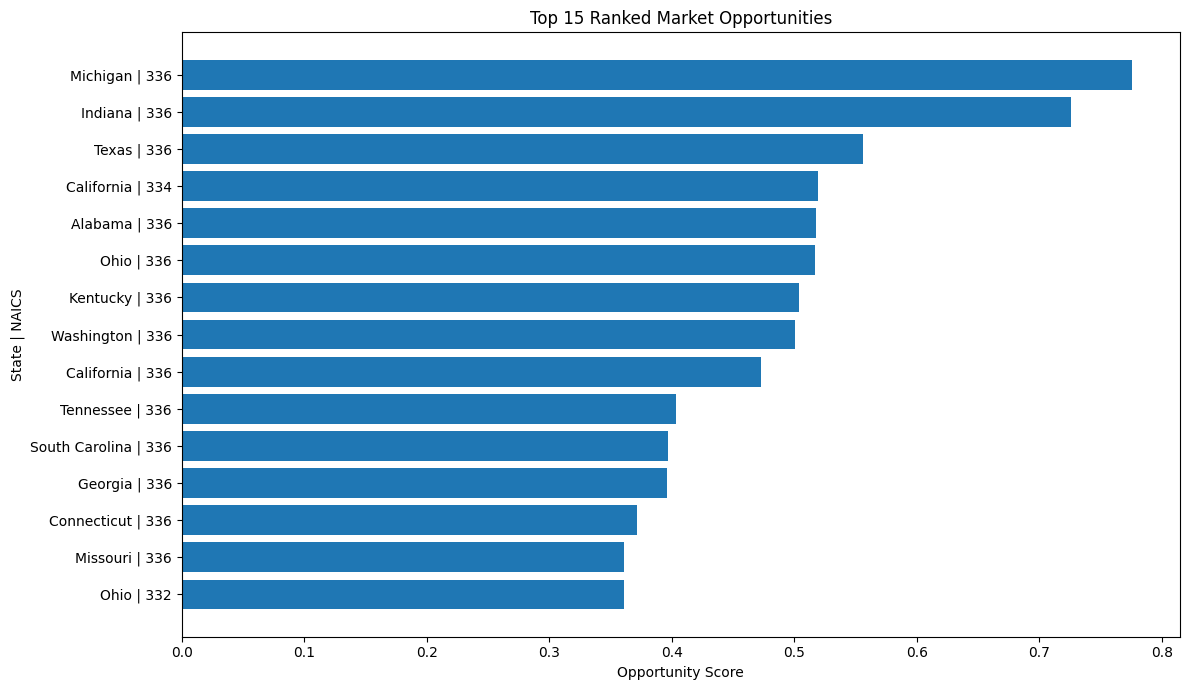

In [50]:
# Visualizing top 15 ranked opportunities
import matplotlib.pyplot as plt

top15 = viz_df.sort_values("opportunity_score", ascending=False).head(15).copy()
top15["label"] = top15["state_name"] + " | " + top15["naics"].astype(str)

plt.figure(figsize=(12, 7))
plt.barh(top15["label"], top15["opportunity_score"])
plt.xlabel("Opportunity Score")
plt.ylabel("State | NAICS")
plt.title("Top 15 Ranked Market Opportunities")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [51]:
# Showing NAICS labels for reference
relevant_naics_map = pd.read_sql_query("""
SELECT DISTINCT
    naics,
    industry
FROM asm_clean
WHERE naics IN (332, 333, 334, 335, 336)
ORDER BY naics;
""", conn)

relevant_naics_map

,naics,industry
0,332,Fabricated metal product manufacturing
1,333,Machinery manufacturing
2,334,Computer and electronic product manufacturing
3,335,"Electrical equipment, appliance, and component..."
4,336,Transportation equipment manufacturing


###Note: Opportunity Score Ranking

The clustering results group state–industry combinations into distinct profiles based on scale, growth, and overall opportunity. In the chart above, the top entries are dominated by NAICS 336 (Transportation Equipment Manufacturing), with states such as South Carolina, Georgia, Connecticut, and Missouri appearing prominently.

These bars represent the highest-scoring observations within the cluster, indicating that this industry consistently forms a top-tier opportunity group across multiple regions. This aligns with earlier findings, where transportation-related industries ranked highly in both receipts and growth.

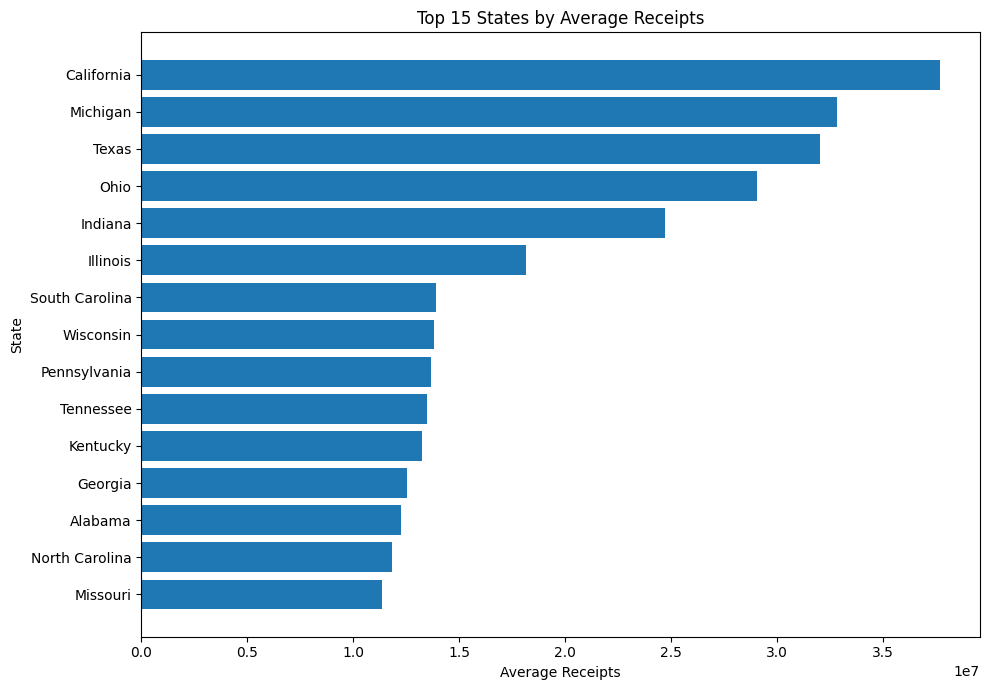

In [52]:
# Visualizing top 15 states by overall revenue
state_bar_df = pd.read_sql_query("""
SELECT
    state_name,
    AVG(receipts) AS avg_receipts
FROM asm_clean
WHERE naics IN (332, 333, 334, 335, 336)
GROUP BY state_name
ORDER BY avg_receipts DESC
LIMIT 15;
""", conn)

state_bar_df = state_bar_df.iloc[::-1]

plt.figure(figsize=(10, 7))
plt.barh(state_bar_df["state_name"], state_bar_df["avg_receipts"])
plt.title("Top 15 States by Average Receipts")
plt.xlabel("Average Receipts")
plt.ylabel("State")
plt.tight_layout()
plt.show()

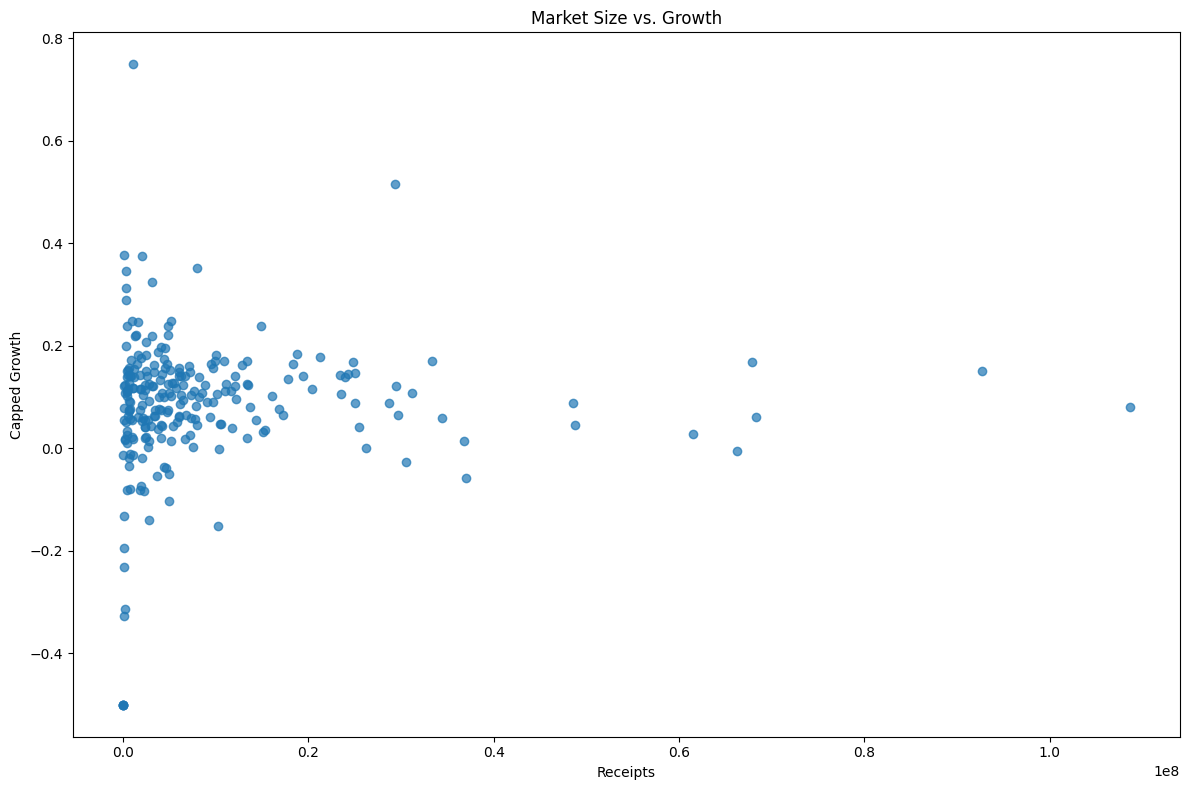

In [53]:
# Visualizing market size vs Growth
plt.figure(figsize=(12, 8))
plt.scatter(
    viz_df["receipts"],
    viz_df["capped_growth"],
    alpha=0.7
)

plt.xlabel("Receipts")
plt.ylabel("Capped Growth")
plt.title("Market Size vs. Growth")
plt.tight_layout()
plt.show()

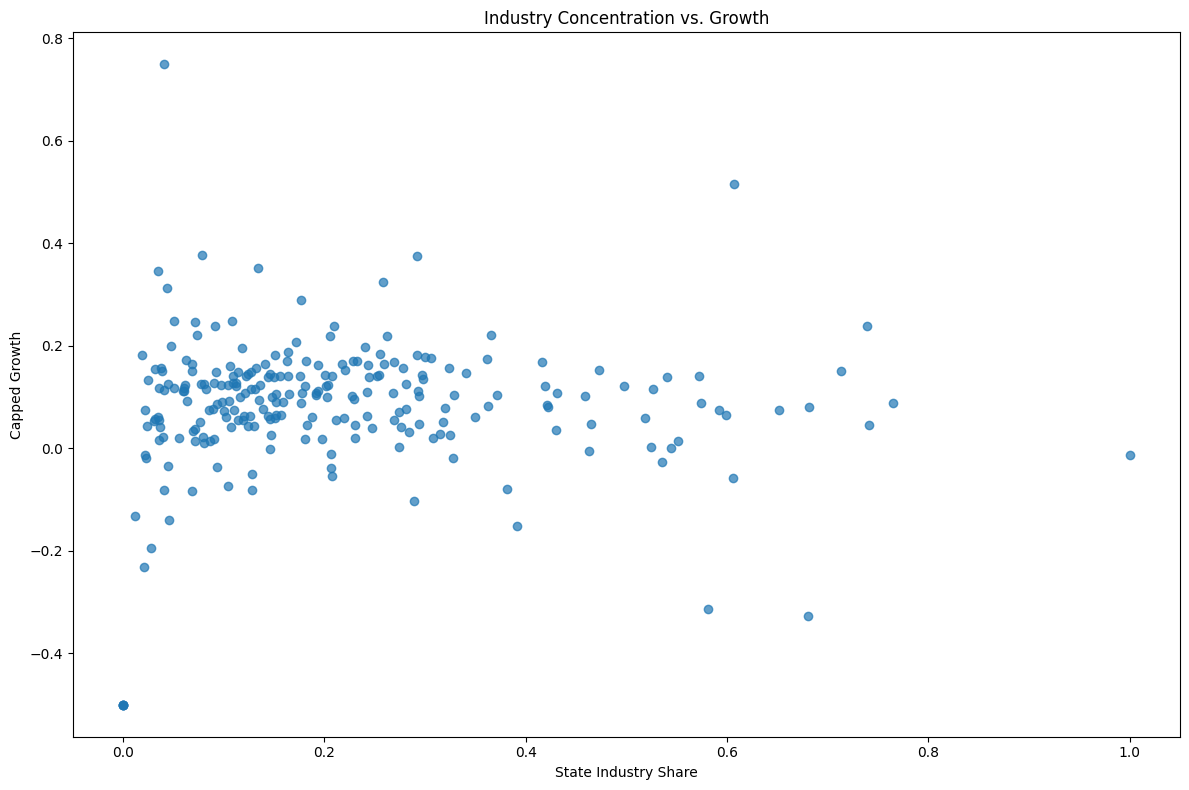

In [54]:
# Visualizing industry concentration vs growth
plt.figure(figsize=(12, 8))
plt.scatter(
    viz_df["state_industry_share"],
    viz_df["capped_growth"],
    alpha=0.7
)

plt.xlabel("State Industry Share")
plt.ylabel("Capped Growth")
plt.title("Industry Concentration vs. Growth")
plt.tight_layout()
plt.show()

###Note: Identifying Priority Points

The scatter plots show a clear structural pattern: larger, more established markets; those with higher receipts and industry share tend to cluster around lower growth rates, indicating maturity and relative stability.

In contrast, emerging or mid-sized markets exhibit significantly greater variation in both growth and concentration, with several outliers demonstrating high growth despite smaller scale.

The most attractive opportunities are not found at the extremes, but in markets that balance meaningful scale with strong growth. While the largest, most established industries tend to exhibit slower growth, and smaller markets show higher volatility, the highest-interest points lie in the upper-right region of the distribution, where both receipts and growth are elevated.

These markets represent a “sweet spot” where there is already sufficient economic size to support investment, combined with continued expansion potential, making them strong candidates for strategic focus.

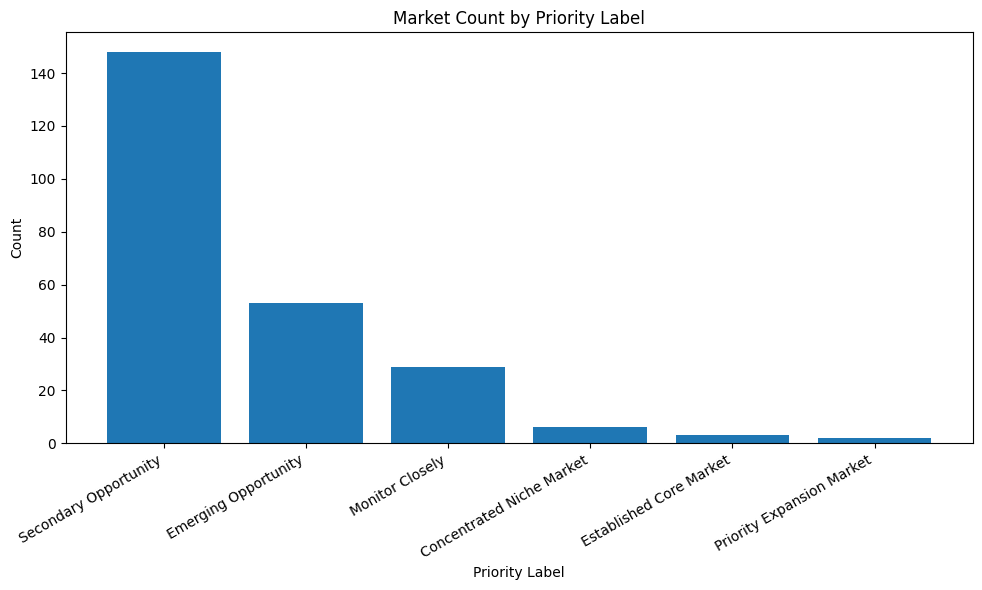

In [55]:
# Counts of markets by priority label
label_counts = (
    viz_df["priority_label"]
    .value_counts()
    .reset_index()
)
label_counts.columns = ["priority_label", "count"]

plt.figure(figsize=(10, 6))
plt.bar(label_counts["priority_label"], label_counts["count"])
plt.xticks(rotation=30, ha="right")
plt.xlabel("Priority Label")
plt.ylabel("Count")
plt.title("Market Count by Priority Label")
plt.tight_layout()
plt.show()

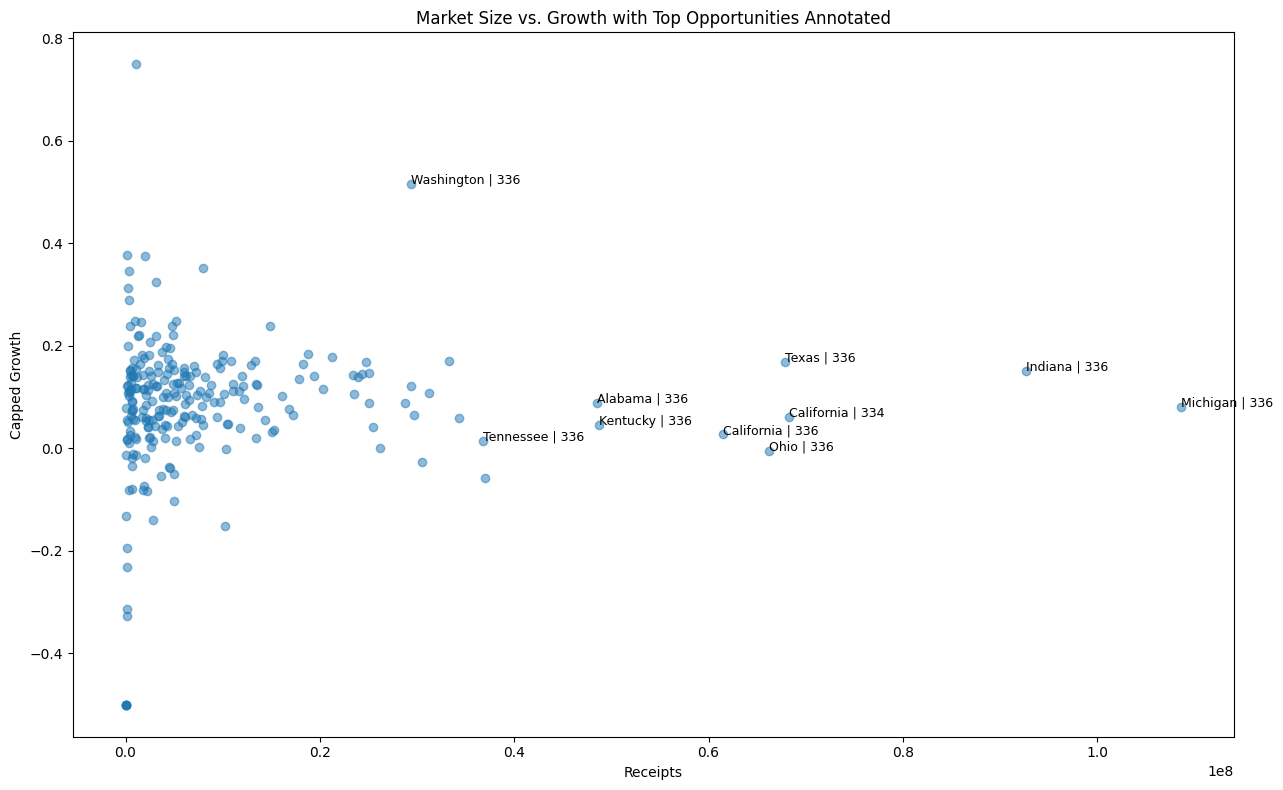

In [56]:
top_annotate = viz_df.sort_values("opportunity_score", ascending=False).head(10).copy()

plt.figure(figsize=(13, 8))
plt.scatter(
    viz_df["receipts"],
    viz_df["capped_growth"],
    alpha=0.5
)

for _, row in top_annotate.iterrows():
    plt.annotate(
        f"{row['state_name']} | {row['naics']}",
        (row["receipts"], row["capped_growth"]),
        fontsize=9
    )

plt.xlabel("Receipts")
plt.ylabel("Capped Growth")
plt.title("Market Size vs. Growth with Top Opportunities Annotated")
plt.tight_layout()
plt.show()

###Note:

While the largest markets tend to exhibit slower growth, they can still rank highly in the scoring model due to their scale and strong regional concentration. As a result, high-revenue industries such as transportation equipment manufacturing in states like Michigan remain priority opportunities despite more moderate growth rates.

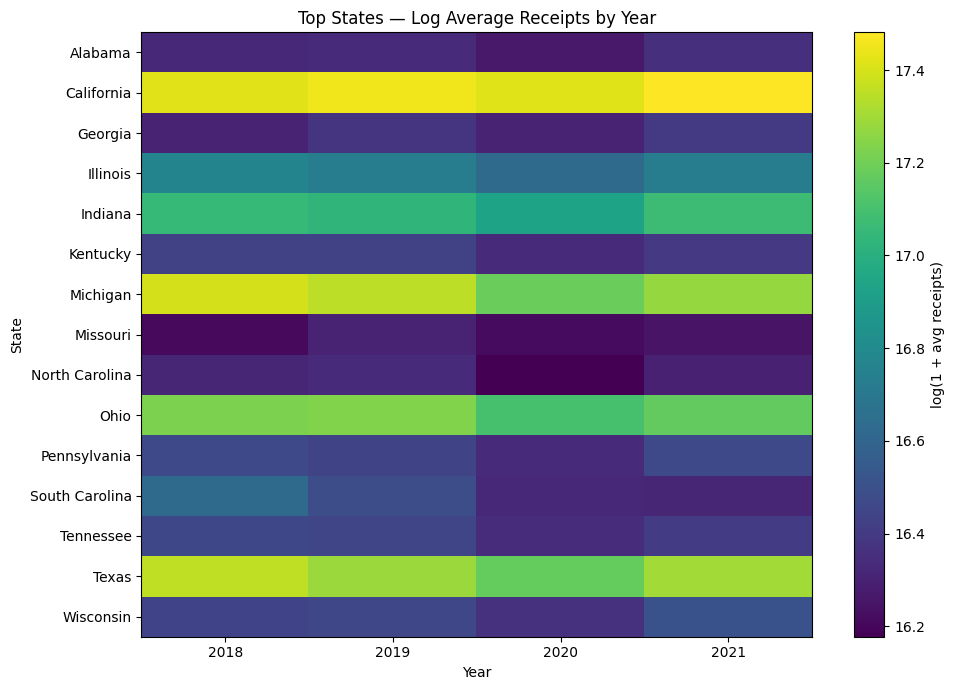

In [57]:
state_df = pd.read_sql_query("""
SELECT
    state_name,
    year,
    AVG(receipts) AS avg_receipts
FROM asm_clean
WHERE naics IN (332, 333, 334, 335, 336)
GROUP BY state_name, year
ORDER BY state_name, year;
""", conn)

top_states = (
    state_df.groupby("state_name")["avg_receipts"]
    .mean()
    .sort_values(ascending=False)
    .head(15)
    .index
)

state_df = state_df[state_df["state_name"].isin(top_states)]
state_pivot = state_df.pivot(index="state_name", columns="year", values="avg_receipts")
state_log = np.log1p(state_pivot)

plt.figure(figsize=(10, 7))
plt.imshow(state_log, aspect="auto")
plt.colorbar(label="log(1 + avg receipts)")
plt.xticks(range(len(state_log.columns)), state_log.columns)
plt.yticks(range(len(state_log.index)), state_log.index)
plt.title("Top States — Log Average Receipts by Year")
plt.xlabel("Year")
plt.ylabel("State")
plt.tight_layout()
plt.show()

###Observations:

The heatmap highlights a clear concentration of strong performance among major industrial states such as California, Michigan, Texas, and Ohio. These states not only represent the largest markets, but also continue to show meaningful growth across the selected industries.

This suggests that while some large markets exhibit signs of maturity, others remain highly competitive due to their ability to sustain both scale and growth. As a result, top opportunities are not limited to emerging markets, but also include established industrial hubs that continue to expand.

In [58]:
# Pulling base table
base_df = pd.read_sql_query("""
SELECT
    state_name,
    naics,
    industry,
    receipts,
    capped_growth,
    state_industry_share,
    opportunity_score,
    priority_label,
    market_type
FROM asm_recommendations_base
ORDER BY opportunity_score DESC;
""", conn)

# Merging cluster labels from clustering step
llm_df = base_df.merge(
    cluster_df[["state_name", "naics", "industry", "cluster"]],
    on=["state_name", "naics", "industry"],
    how="left"
)

llm_df.head()

,state_name,naics,industry,receipts,capped_growth,state_industry_share,opportunity_score,priority_label,market_type,cluster
0,Michigan,336,Transportation equipment manufacturing,108619945.0,0.081230,0.681680,0.775917,Priority Expansion Market,Large and Expanding,2
1,Indiana,336,Transportation equipment manufacturing,92702900.0,0.151470,0.713324,0.725844,Priority Expansion Market,Large and Expanding,2
2,Texas,336,Transportation equipment manufacturing,67893618.0,0.168686,0.416541,0.556419,Established Core Market,Large and Expanding,2
3,California,334,Computer and electronic product manufacturing,68321679.0,0.062139,0.349493,0.519394,Established Core Market,Large and Expanding,2
4,Alabama,336,Transportation equipment manufacturing,48535643.0,0.089416,0.765167,0.518000,Concentrated Niche Market,Specialized Regional Stronghold,2


In [59]:
# Checking for nulls
llm_df["cluster"].isnull().sum()

np.int64(0)

In [60]:
# Checking final row count
llm_df.to_sql("asm_final_with_cluster", conn, if_exists="replace", index=False)

241

In [61]:
# Showing the step-by-step reduction from filtering
pd.read_sql_query("""
SELECT COUNT(*) AS n
FROM asm_clean;
""", conn)

,n
0,20642


In [62]:
pd.read_sql_query("""
SELECT COUNT(*) AS n
FROM asm_clean
WHERE naics IN (332, 333, 334, 335, 336);
""", conn)

,n
0,1006


In [63]:
pd.read_sql_query("""
SELECT COUNT(*) AS n
FROM asm_features_enriched;
""", conn)

,n
0,1006


In [64]:
pd.read_sql_query("""
SELECT COUNT(*) AS n
FROM asm_features_enriched
WHERE year = (SELECT MAX(year) FROM asm_features_enriched)
  AND receipts_growth IS NOT NULL;
""", conn)

,n
0,241


In [65]:
pd.read_sql_query("""
SELECT COUNT(*) AS n
FROM asm_recommendations_base;
""", conn)

,n
0,241


In [66]:
pd.read_sql_query("""
SELECT COUNT(*) AS n
FROM asm_final_with_cluster;
""", conn)

,n
0,241


###Note: Scale Reduction

The final Stage 3 table contains 241 rows because the pipeline progressively narrows a broad manufacturing dataset into a focused set of decision-ready records.

First, the data is filtered to the most relevant sectors for a large industrial engineering organization, limiting the analysis to key manufacturing domains (NAICS 332–336).

Next, the dataset is reduced to the most recent year only, since the scoring model is designed to evaluate current market opportunities rather than historical trends. Rows without valid year-over-year growth are also removed to ensure all features are complete.

The result is a final table where each row represents a state–industry market with full feature coverage (scale, growth, concentration, and score). Cluster labels are then added without further filtering.

This is why the final table contains 241 rows: it reflects the complete set of relevant, current, and fully usable market records for decision support.

In [67]:
# Installing OpenAI
!pip install openai

import os
from openai import OpenAI

# Make sure your API key is set in the environment before running:
# os.environ["OPENAI_API_KEY"] = "your_api_key_here"

client = OpenAI(api_key=os.environ.get("OPENAI_API_KEY"))

In [68]:
# Testing LLM
response = client.responses.create(
    model="gpt-4.1-nano",
    input="Give me a one sentence test output."
)

print(response.output_text)

This is a one-sentence test output.


In [69]:
# Defining output function
def generate_llm_recommendation(prompt):
    response = client.responses.create(
        model="gpt-4.1-nano",
        input=prompt,
        max_output_tokens=180
    )
    return response.output_text

In [70]:
# 1. Building a compact market context string
def build_market_context(row):
    return f"""
State: {row['state_name']}
NAICS: {row['naics']}
Industry: {row['industry']}
Receipts: {row['receipts']:.2f}
Growth: {row['capped_growth']:.2%}
State Industry Share: {row['state_industry_share']:.2%}
Opportunity Score: {row['opportunity_score']:.3f}
Priority Label: {row['priority_label']}
Market Type: {row['market_type']}
Cluster: {int(row['cluster'])}
""".strip()


# 2. Adding a deterministic business action
def recommended_action(row):
    if row["priority_label"] == "Priority Expansion Market":
        return "Expand sales focus and prioritize partnership development."
    elif row["priority_label"] == "Established Core Market":
        return "Maintain strong commercial coverage and defend market position."
    elif row["priority_label"] == "Emerging Opportunity":
        return "Monitor closely and test targeted business development efforts."
    elif row["priority_label"] == "Concentrated Niche Market":
        return "Pursue selective partnerships and specialized account targeting."
    elif row["priority_label"] == "Monitor Closely":
        return "Limit immediate expansion and continue watching market signals."
    else:
        return "Maintain awareness and evaluate for selective engagement."


# 3. Building the LLM prompt
def build_llm_prompt(row):
    return f"""
You are an industrial market strategy analyst supporting a company like Morris Group International.

Interpret the structured market profile below and produce a concise executive recommendation.

Market profile:
{row['market_context']}

Suggested business action:
{row['recommended_action']}

Write exactly these sections:
Executive Summary:
Recommended Action:
Why It Matters:

Constraints:
- Use only the provided data
- Treat opportunity as commercial opportunity, not stock investing
- Keep the tone concise, professional, and executive-facing
- Do not invent company names, partnerships, or competitive facts
""".strip()


# 4. Applying helper columns to the full dataframe
llm_df["market_context"] = llm_df.apply(build_market_context, axis=1)
llm_df["recommended_action"] = llm_df.apply(recommended_action, axis=1)
llm_df["llm_prompt"] = llm_df.apply(build_llm_prompt, axis=1)

# 5. Creating a smaller subset for generation
llm_df_top = llm_df.head(5).copy()

# Checking output prompt column
llm_df_top[["state_name", "industry", "llm_prompt"]].head()

,state_name,industry,llm_prompt
0,Michigan,Transportation equipment manufacturing,You are an industrial market strategy analyst ...
1,Indiana,Transportation equipment manufacturing,You are an industrial market strategy analyst ...
2,Texas,Transportation equipment manufacturing,You are an industrial market strategy analyst ...
3,California,Computer and electronic product manufacturing,You are an industrial market strategy analyst ...
4,Alabama,Transportation equipment manufacturing,You are an industrial market strategy analyst ...


In [71]:
# Defining function to generate the recommendation
def generate_llm_recommendation(prompt):
    response = client.responses.create(
        model="gpt-4.1-nano",
        input=prompt,
        max_output_tokens=180
    )
    return response.output_text

llm_df_top["llm_recommendation"] = llm_df_top["llm_prompt"].apply(generate_llm_recommendation)

In [72]:
# Importing regex
import re

# Defining parsing function
def parse_llm_output(text):
    sections = {
        "executive_summary": "",
        "recommended_action_llm": "",
        "why_it_matters": ""
    }

    try:
        sections["executive_summary"] = re.search(
            r"Executive Summary:\s*(.*?)(?=Recommended Action:)", text, re.S
        ).group(1).strip()

        sections["recommended_action_llm"] = re.search(
            r"Recommended Action:\s*(.*?)(?=Why It Matters:)", text, re.S
        ).group(1).strip()

        sections["why_it_matters"] = re.search(
            r"Why It Matters:\s*(.*)", text, re.S
        ).group(1).strip()

    except:
        pass  # fallback if formatting slightly off

    return pd.Series(sections)


# Apply parsing
parsed_cols = llm_df_top["llm_recommendation"].apply(parse_llm_output)

llm_df_top = pd.concat([llm_df_top, parsed_cols], axis=1)

In [78]:
# Appedning table with recommended action column
final_output = llm_df_top[[
    "state_name",
    "industry",
    "opportunity_score",
    "cluster",
    "priority_label",
    "market_type",
    "executive_summary",
    "recommended_action_llm"
]].sort_values(by="opportunity_score", ascending=False)

final_output

,state_name,industry,opportunity_score,cluster,priority_label,market_type,executive_summary,recommended_action_llm
0,Michigan,Transportation equipment manufacturing,0.775917,2,Priority Expansion Market,Large and Expanding,The Michigan transportation equipment manufact...,Accelerate sales initiatives and develop strat...
1,Indiana,Transportation equipment manufacturing,0.725844,2,Priority Expansion Market,Large and Expanding,Indiana's transportation equipment manufacturi...,Expand sales initiatives and prioritize partne...
2,Texas,Transportation equipment manufacturing,0.556419,2,Established Core Market,Large and Expanding,The Texas NAICS 336 transportation equipment m...,Maintain strong commercial coverage and active...
3,California,Computer and electronic product manufacturing,0.519394,2,Established Core Market,Large and Expanding,The California market within the NAICS 334 sec...,Maintain strong commercial coverage to defend ...
4,Alabama,Transportation equipment manufacturing,0.518000,2,Concentrated Niche Market,Specialized Regional Stronghold,Alabama's transportation equipment manufacturi...,Prioritize selective partnerships and targeted...


In [74]:
# Importing new column to SQL
final_output.to_sql(
    "asm_llm_recommendations",
    conn,
    if_exists="replace",
    index=False
)

5

In [75]:
# Filtering final table to most important categories
actionable = final_output[
    final_output["priority_label"].isin([
        "Priority Expansion Market",
        "Established Core Market"
    ])
]

In [76]:
# Defining function to assign opportunity tier
def assign_tier(score):
    if score > 0.7:
        return "Tier 1"
    elif score > 0.5:
        return "Tier 2"
    else:
        return "Tier 3"

final_output["tier"] = final_output["opportunity_score"].apply(assign_tier)

In [81]:
# Generating sample LLM recommendation for each opportunity tier
import textwrap

top_n = 3
top_recs = final_output.head(top_n)

for i, row in top_recs.iterrows():
    print("=" * 80)

    print(f"Market: {row['state_name']} | {row['industry']}")
    print(f"Opportunity Score: {round(row['opportunity_score'], 3)}\n")

    print("Recommended Action:")
    print(textwrap.fill(row['recommended_action_llm'], width=90))

    print("=" * 80 + "\n")

Market: Michigan | Transportation equipment manufacturing
Opportunity Score: 0.776

Recommended Action:
Accelerate sales initiatives and develop strategic partnerships within Michigan’s
transportation manufacturing segment to capitalize on market momentum and maximize revenue
opportunities.

Market: Indiana | Transportation equipment manufacturing
Opportunity Score: 0.726

Recommended Action:
Expand sales initiatives and prioritize partnership development within Indiana’s
transportation equipment manufacturing industry to capitalize on its growth trajectory and
market dominance.

Market: Texas | Transportation equipment manufacturing
Opportunity Score: 0.556

Recommended Action:
Maintain strong commercial coverage and actively defend market position to capitalize on
the market’s growth and prominence.



In [82]:
# Creating query box for interactive LLM use
# Installing ipywidgets

import ipywidgets as widgets
from IPython.display import display, Markdown, clear_output
import pandas as pd
import re

# ---- 1. Basic retrieval helper ----
def retrieve_relevant_rows(question, df, top_k=12):
    q = question.lower()

    # keyword matching score
    def row_score(row):
        score = 0
        state = str(row["state_name"]).lower()
        industry = str(row["industry"]).lower()
        priority = str(row.get("priority_label", "")).lower()
        market_type = str(row.get("market_type", "")).lower()

        # direct text matches
        for token in re.findall(r"\w+", q):
            if token in state:
                score += 3
            if token in industry:
                score += 4
            if token in priority:
                score += 2
            if token in market_type:
                score += 2

        # useful boosts for common business questions
        if "top" in q or "best" in q or "highest" in q:
            score += float(row["opportunity_score"]) * 5

        if "growth" in q or "growing" in q or "fastest" in q:
            score += max(float(row["capped_growth"]), 0) * 10

        if "concentrated" in q or "specialized" in q or "clustered" in q:
            score += float(row["state_industry_share"]) * 5

        if "large" in q or "biggest" in q or "market size" in q:
            score += float(row["receipts"]) / max(df["receipts"].max(), 1)

        return score

    scored = df.copy()
    scored["retrieval_score"] = scored.apply(row_score, axis=1)
    scored = scored.sort_values(["retrieval_score", "opportunity_score"], ascending=False)

    # if everything scores 0, default to highest-opportunity markets
    if scored["retrieval_score"].max() == 0:
        scored = scored.sort_values("opportunity_score", ascending=False)

    return scored.head(top_k).copy()


# ---- 2. Format retrieved rows into compact context ----
def build_context_table(df_subset):
    lines = []
    for _, row in df_subset.iterrows():
        lines.append(
            f"- State: {row['state_name']} | "
            f"Industry: {row['industry']} | "
            f"NAICS: {row['naics']} | "
            f"Opportunity Score: {row['opportunity_score']:.3f} | "
            f"Growth: {row['capped_growth']:.2%} | "
            f"Industry Share: {row['state_industry_share']:.2%} | "
            f"Priority: {row['priority_label']} | "
            f"Market Type: {row['market_type']} | "
            f"Cluster: {row['cluster']}"
        )
    return "\n".join(lines)


# ---- 3. LLM answer function ----
def ask_market_llm(question, df, top_k=12, model="gpt-4.1-nano"):
    retrieved = retrieve_relevant_rows(question, df, top_k=top_k)
    context = build_context_table(retrieved)

    prompt = f"""
You are an industrial market intelligence analyst supporting a company like Morris Group International.

Use only the retrieved market records below to answer the user's question.
If the data is insufficient to fully answer, say so explicitly.
Do not invent facts.
Treat opportunity as commercial opportunity: sales focus, territory prioritization, partnership targeting, and market development.

User question:
{question}

Retrieved records:
{context}

Return:
1. A direct answer to the question
2. A short evidence-based explanation using the retrieved records
3. If appropriate, a practical recommendation
""".strip()

    response = client.responses.create(
        model=model,
        input=prompt,
        max_output_tokens=500
    )

    return response.output_text, retrieved


# ---- 4. Interactive widgets ----
question_box = widgets.Textarea(
    value="What are the top expansion markets and why?",
    placeholder="Ask a question about the market data...",
    description="Question:",
    layout=widgets.Layout(width="100%", height="100px")
)

run_button = widgets.Button(
    description="Ask LLM",
    button_style="primary"
)

output = widgets.Output()

def on_run_clicked(_):
    with output:
        clear_output()
        question = question_box.value.strip()

        if not question:
            print("Please enter a question.")
            return

        try:
            answer, retrieved = ask_market_llm(question, llm_df, top_k=10, model="gpt-4.1-nano")
            display(Markdown("## Answer"))
            display(Markdown(answer))

            display(Markdown("## Retrieved Market Records Used"))
            display(retrieved[[
                "state_name",
                "industry",
                "naics",
                "opportunity_score",
                "capped_growth",
                "state_industry_share",
                "priority_label",
                "market_type",
                "cluster"
            ]].reset_index(drop=True))

        except Exception as e:
            print(f"Error: {e}")

run_button.on_click(on_run_clicked)

display(question_box, run_button, output)

Textarea(value='What are the top expansion markets and why?', description='Question:', layout=Layout(height='1…

Button(button_style='primary', description='Ask LLM', style=ButtonStyle())

Output()

In [83]:
# Converting data to csv
final_output.to_csv("market_opportunities.csv", index=False)

In [84]:
# Exporting csv for dashboard use
from google.colab import files
files.download("market_opportunities.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

#Conclusion

This notebook demonstrates how raw industrial data can be transformed into a structured decision-support system for a large industrial engineering organization. Starting from broad NAICS-level economic data, the pipeline progressively narrows the scope to relevant sectors, engineers key features (scale, growth, and concentration) and combines them into a weighted scoring model to evaluate market opportunity.

The analysis reveals a clear tradeoff between market size and growth: large, established industries tend to exhibit more stable, slower growth, while smaller markets show greater variability and upside potential. The most attractive opportunities emerge where these factors intersect—markets that are large enough to matter, but still actively growing.

By layering rule-based categorizations and clustering on top of the scoring model, the system moves beyond ranking into interpretable segmentation, allowing markets to be grouped into actionable categories such as expansion targets, core markets and emerging opportunities.

The final output, a filtered set of high-priority, feature-complete market records, represents a practical foundation for downstream use, including integration with LLMs for natural language insights or internal deployment in decision-support dashboards.

Overall, this approach illustrates how combining structured data processing with simple modeling techniques can produce clear, scalable insights for strategic planning in complex industrial environments.